# AI Car Price Advisor — Exploratory Data Analysis

This notebook performs exploratory data analysis on the AutoScout24 car dataset and the CarBodyStyles image dataset used for training the AI Car Price Advisor.

**Dataset:** `cars_project.csv` (AutoScout24 listings, n ≈ 8,300)

**Sections:**
1. Dataset overview
2. Price distribution
3. Body type distribution
4. Manufacturer distribution
5. Fuel type distribution
6. Mileage distribution
7. Correlation analysis
8. Outlier analysis
9. Feature engineering exploration
10. Image dataset overview

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

BASE_DIR = Path('.').resolve()
DATA_PATH = BASE_DIR.parent / 'cars_project.csv'
IMAGE_DIR = BASE_DIR.parent / 'CarBodyStyles'

print(f'Data path: {DATA_PATH}')
print(f'Image dir: {IMAGE_DIR}')

Data path: C:\github\ai-applications-main\Projekt\cars_project.csv
Image dir: C:\github\ai-applications-main\Projekt\CarBodyStyles


## 1. Dataset Overview

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (8313, 8)
Columns: ['price', 'make', 'model', 'mileage_km', 'registration_date', 'body_type', 'transmission', 'primary_fuel']


,price,make,model,mileage_km,registration_date,body_type,transmission,primary_fuel
0,181580.0,BMW,750,1.0,2025-01-01,Sedan,Automatic,Super 95
1,37500.0,BMW,X4,50009.0,2021-01-01,SUV,Automatic,Super 95
2,49500.0,BMW,M2,27000.0,2020-05-01,Coupe,Automatic,Super Plus E10 98
3,12900.0,BMW,118,143603.0,2015-12-01,Hatchback,Automatic,Super 95
4,67900.0,Porsche,Panamera,75000.0,2020-08-01,Sedan,Automatic,Super 95


In [3]:
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())

Data types:
price                float64
make                     str
model                    str
mileage_km           float64
registration_date        str
body_type                str
transmission             str
primary_fuel             str
dtype: object

Missing values:
price                0
make                 0
model                0
mileage_km           0
registration_date    0
body_type            0
transmission         0
primary_fuel         0
dtype: int64


In [4]:
df.describe()

,price,mileage_km
count,8.313000e+03,8.313000e+03
mean,6.047119e+04,5.826961e+04
std,1.154554e+05,6.848876e+04
min,4.900000e+02,0.000000e+00
25%,2.699900e+04,9.900000e+03
50%,4.499000e+04,3.199000e+04
75%,7.248000e+04,9.234300e+04
max,8.627500e+06,2.424696e+06


## 2. Price Distribution

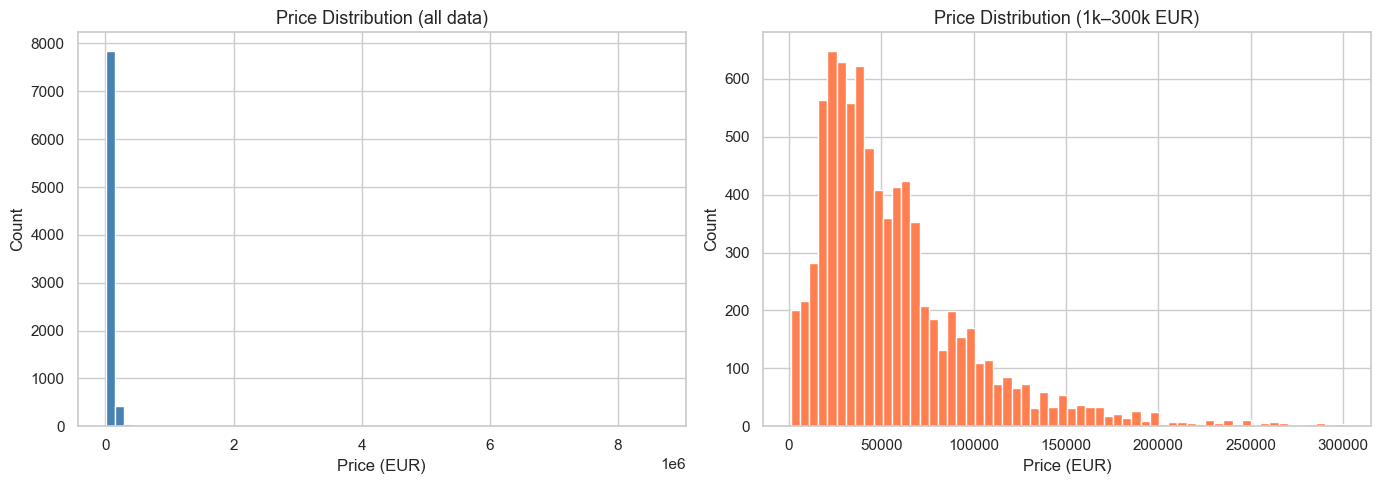

Mean price:   EUR 56,905
Median price: EUR 44,900
Std price:    EUR 43,404


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=60, edgecolor='white', color='steelblue')
axes[0].set_title('Price Distribution (all data)', fontsize=13)
axes[0].set_xlabel('Price (EUR)')
axes[0].set_ylabel('Count')

# Clip extreme outliers for visualization
df_clip = df[(df['price'] >= 1000) & (df['price'] <= 300000)]
axes[1].hist(df_clip['price'], bins=60, edgecolor='white', color='coral')
axes[1].set_title('Price Distribution (1k–300k EUR)', fontsize=13)
axes[1].set_xlabel('Price (EUR)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Mean price:   EUR {df_clip["price"].mean():,.0f}')
print(f'Median price: EUR {df_clip["price"].median():,.0f}')
print(f'Std price:    EUR {df_clip["price"].std():,.0f}')

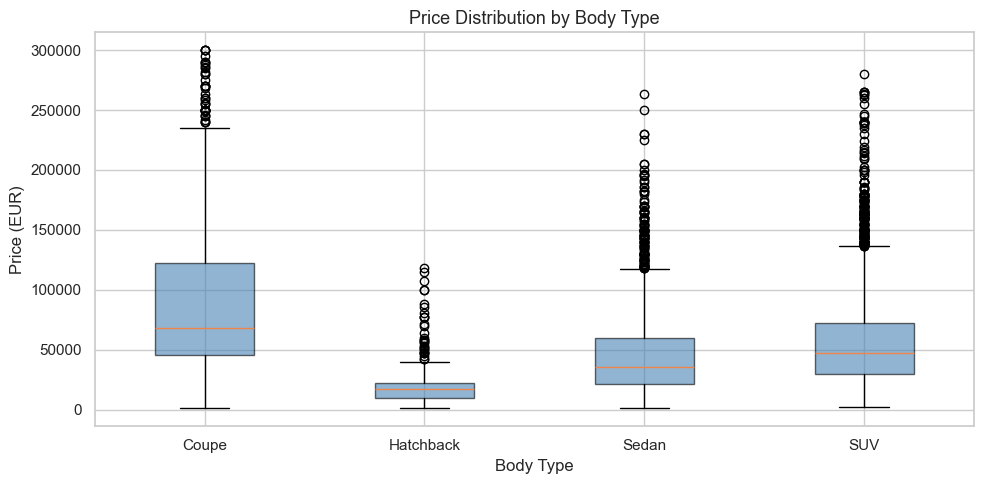

Coupe       : median=  68,465 EUR | mean=  90,540 EUR | n=1176
Hatchback   : median=  17,495 EUR | mean=  20,494 EUR | n=334
Sedan       : median=  35,890 EUR | mean=  45,144 EUR | n=2286
SUV         : median=  46,990 EUR | mean=  56,792 EUR | n=4461


In [6]:
# Price by body type boxplot
BODY_TYPES = ['Coupe', 'Hatchback', 'Sedan', 'SUV']
df_clean = df[df['body_type'].isin(BODY_TYPES) & (df['price'] >= 1000) & (df['price'] <= 300000)]

fig, ax = plt.subplots(figsize=(10, 5))
groups = [df_clean[df_clean['body_type'] == bt]['price'].values for bt in BODY_TYPES]
ax.boxplot(groups, labels=BODY_TYPES, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_title('Price Distribution by Body Type', fontsize=13)
ax.set_xlabel('Body Type')
ax.set_ylabel('Price (EUR)')
plt.tight_layout()
plt.show()

for bt in BODY_TYPES:
    sub = df_clean[df_clean['body_type'] == bt]['price']
    print(f'{bt:12s}: median={sub.median():>8,.0f} EUR | mean={sub.mean():>8,.0f} EUR | n={len(sub)}')

## 3. Body Type Distribution

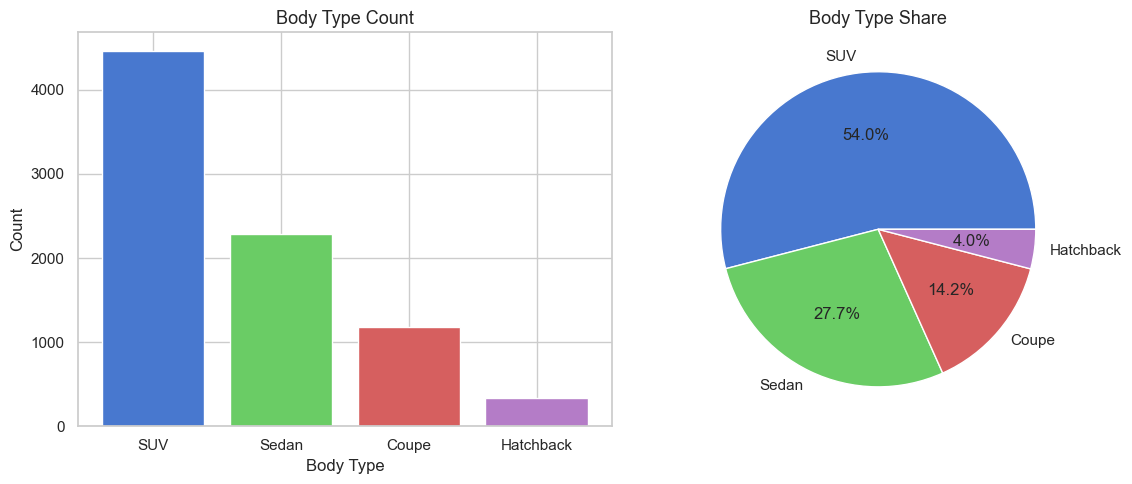

body_type
SUV          4461
Sedan        2286
Coupe        1176
Hatchback     334
Name: count, dtype: int64


In [7]:
bt_counts = df_clean['body_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(bt_counts.index, bt_counts.values, color=['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7'])
axes[0].set_title('Body Type Count', fontsize=13)
axes[0].set_xlabel('Body Type')
axes[0].set_ylabel('Count')

axes[1].pie(bt_counts.values, labels=bt_counts.index, autopct='%1.1f%%',
            colors=['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7'])
axes[1].set_title('Body Type Share', fontsize=13)

plt.tight_layout()
plt.show()
print(bt_counts)

## 4. Vehicle Manufacturer Distribution

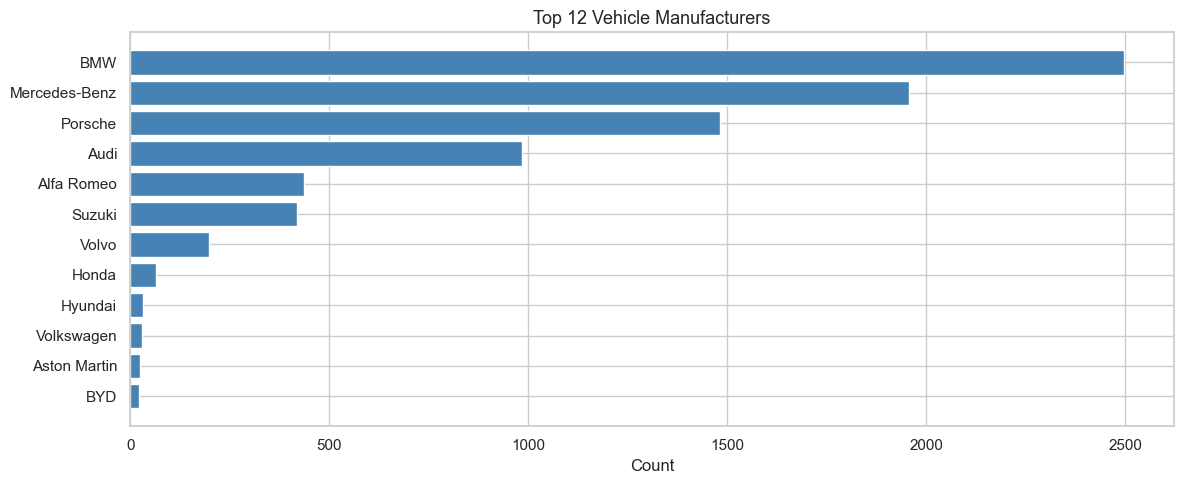

make
BMW              2498
Mercedes-Benz    1956
Porsche          1482
Audi              985
Alfa Romeo        436
Suzuki            418
Volvo             197
Honda              64
Hyundai            33
Volkswagen         30
Aston Martin       25
BYD                23
Name: count, dtype: int64


In [8]:
make_counts = df_clean['make'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(make_counts.index[::-1], make_counts.values[::-1], color='steelblue')
ax.set_title('Top 12 Vehicle Manufacturers', fontsize=13)
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()
print(make_counts)

## 5. Fuel Type Distribution

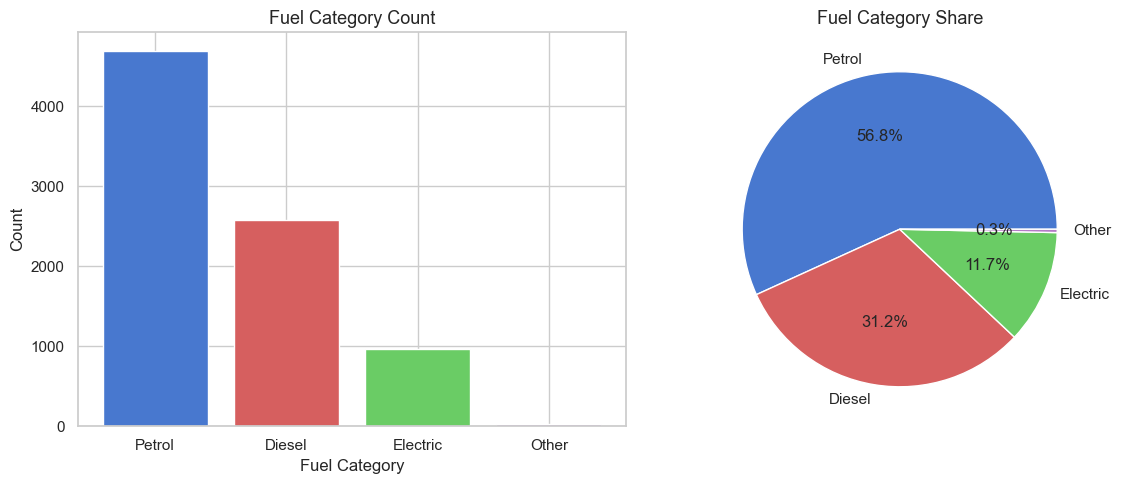

In [9]:
FUEL_MAPPING = {
    'Super 95': 'Petrol', 'Super Plus E10 98': 'Petrol',
    'Super E10 95': 'Petrol', 'Regular/Benzine 91': 'Petrol',
    'Regular/Benzine E10 91': 'Petrol', 'Super Plus 98': 'Petrol',
    'Diesel': 'Diesel', 'Biodiesel': 'Diesel',
    'Electricity': 'Electric',
    'Liquid petroleum gas (LPG)': 'Other',
    'Domestic gas H': 'Other', 'Vegetable oil': 'Other',
}

df_clean = df_clean.copy()
df_clean['fuel_category'] = df_clean['primary_fuel'].map(FUEL_MAPPING).fillna('Other')

fuel_counts = df_clean['fuel_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(fuel_counts.index, fuel_counts.values, color=['#4878CF', '#D65F5F', '#6ACC65', '#B47CC7'])
axes[0].set_title('Fuel Category Count', fontsize=13)
axes[0].set_xlabel('Fuel Category')
axes[0].set_ylabel('Count')

axes[1].pie(fuel_counts.values, labels=fuel_counts.index, autopct='%1.1f%%',
            colors=['#4878CF', '#D65F5F', '#6ACC65', '#B47CC7'])
axes[1].set_title('Fuel Category Share', fontsize=13)

plt.tight_layout()
plt.show()

## 6. Mileage Distribution

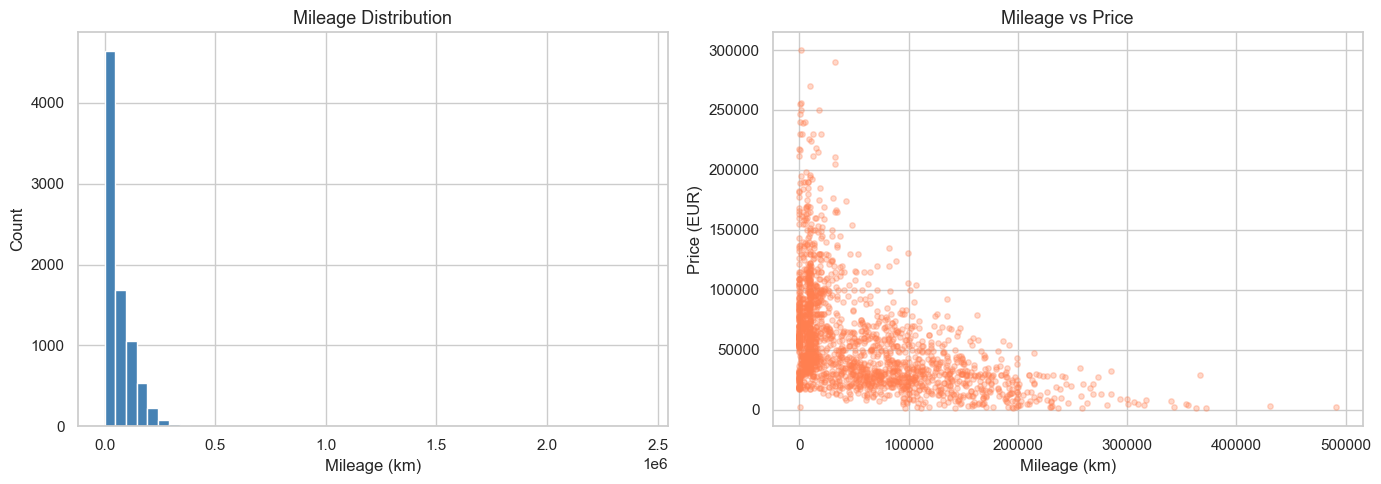

Median mileage: 32,500 km
Mean mileage:   58,530 km


In [10]:
df_clean['mileage_km'] = pd.to_numeric(df_clean['mileage_km'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['mileage_km'].dropna(), bins=50, edgecolor='white', color='steelblue')
axes[0].set_title('Mileage Distribution', fontsize=13)
axes[0].set_xlabel('Mileage (km)')
axes[0].set_ylabel('Count')

# Mileage vs Price scatter
sample = df_clean.dropna(subset=['mileage_km']).sample(min(2000, len(df_clean)), random_state=42)
axes[1].scatter(sample['mileage_km'], sample['price'], alpha=0.3, s=15, c='coral')
axes[1].set_title('Mileage vs Price', fontsize=13)
axes[1].set_xlabel('Mileage (km)')
axes[1].set_ylabel('Price (EUR)')

plt.tight_layout()
plt.show()

print(f'Median mileage: {df_clean["mileage_km"].median():,.0f} km')
print(f'Mean mileage:   {df_clean["mileage_km"].mean():,.0f} km')

## 7. Feature Engineering

In [11]:
CURRENT_YEAR = 2024

df_clean['registration_year'] = pd.to_datetime(df_clean['registration_date'], errors='coerce').dt.year
df_clean['car_age'] = (CURRENT_YEAR - df_clean['registration_year']).clip(lower=1)
df_clean['mileage_per_year'] = df_clean['mileage_km'] / df_clean['car_age']

print('Feature engineering — new columns:')
print(df_clean[['car_age', 'mileage_km', 'mileage_per_year', 'price']].describe())

Feature engineering — new columns:
           car_age    mileage_km  mileage_per_year          price
count  8257.000000  8.257000e+03      8.257000e+03    8257.000000
mean      3.786605  5.852983e+04      1.594799e+04   56905.496548
std       4.358871  6.851830e+04      2.940275e+04   43404.370981
min       1.000000  0.000000e+00      0.000000e+00    1000.000000
25%       1.000000  9.900000e+03      7.920000e+03   26990.000000
50%       2.000000  3.250000e+04      1.278200e+04   44900.000000
75%       5.000000  9.263400e+04      2.142843e+04   71900.000000
max      66.000000  2.424696e+06      2.424696e+06  299900.000000


## 8. Correlation Analysis

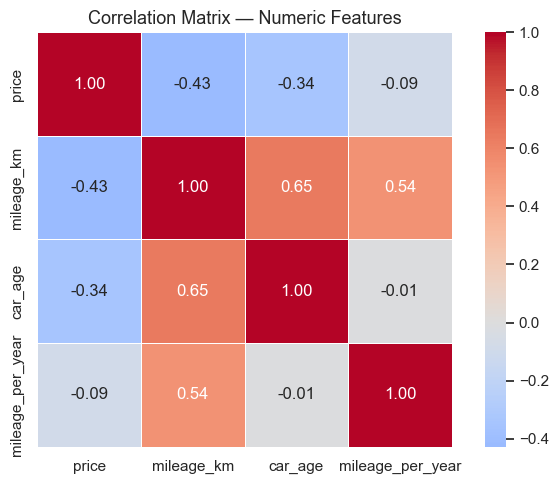

Correlation with Price:
mileage_km         -0.427873
car_age            -0.344467
mileage_per_year   -0.089570
Name: price, dtype: float64


In [12]:
num_cols = ['price', 'mileage_km', 'car_age', 'mileage_per_year']
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

print('Correlation with Price:')
print(corr['price'].drop('price').sort_values(key=abs, ascending=False))

## 9. Outlier Analysis

Price quantiles:
0.01      EUR 2,999
0.05     EUR 10,927
0.25     EUR 26,999
0.50     EUR 44,990
0.75     EUR 72,480
0.95    EUR 149,927
0.99    EUR 255,791
Name: price, dtype: str

Prices > 300k: 51
Prices < 1k:   5


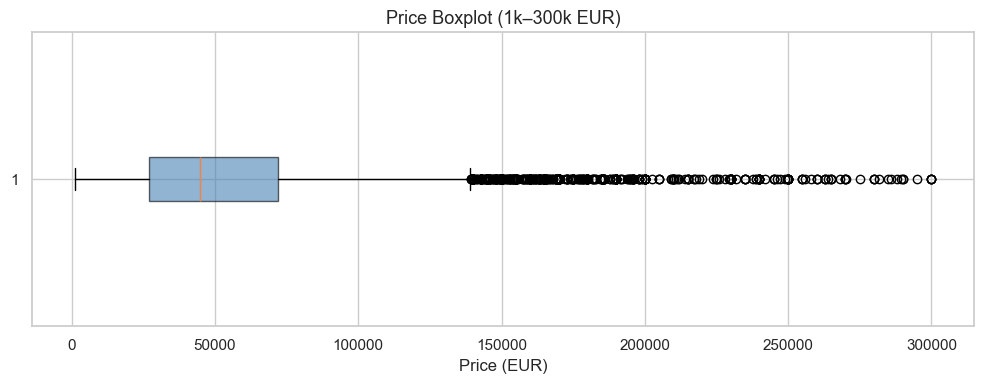

In [13]:
print('Price quantiles:')
print(df['price'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).apply(lambda x: f'EUR {x:,.0f}'))

print(f'\nPrices > 300k: {(df["price"] > 300_000).sum()}')
print(f'Prices < 1k:   {(df["price"] < 1_000).sum()}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(df_clean['price'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_title('Price Boxplot (1k–300k EUR)', fontsize=13)
ax.set_xlabel('Price (EUR)')
plt.tight_layout()
plt.show()

## 10. Image Dataset Overview

In [14]:
print('CarBodyStyles image dataset:')
print('-' * 35)
total = 0
for cls in ['Coupe', 'Hatchback', 'Sedan', 'SUV']:
    cls_dir = IMAGE_DIR / cls
    if cls_dir.exists():
        count = len(list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.jpeg')) + list(cls_dir.glob('*.png')))
        total += count
        print(f'  {cls:12s}: {count:4d} images')
print(f'  {"TOTAL":12s}: {total:4d} images')

CarBodyStyles image dataset:
-----------------------------------
  Coupe       :  466 images
  Hatchback   :  527 images
  Sedan       :  501 images
  SUV         :  847 images
  TOTAL       : 2341 images


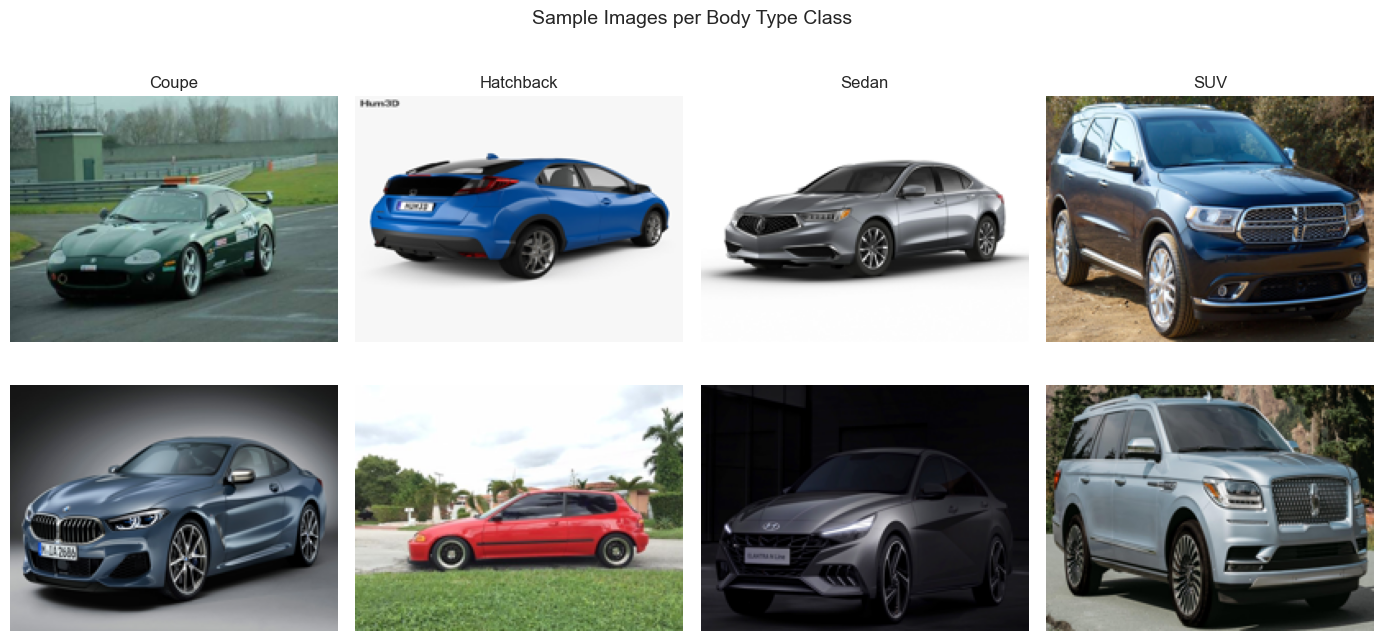

In [15]:
from PIL import Image as PILImage
import random

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Images per Body Type Class', fontsize=14)

for col, cls in enumerate(['Coupe', 'Hatchback', 'Sedan', 'SUV']):
    cls_dir = IMAGE_DIR / cls
    if cls_dir.exists():
        images = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.jpeg'))
        if images:
            for row in range(2):
                img_path = random.choice(images)
                img = PILImage.open(img_path).convert('RGB')
                img = img.resize((200, 150))
                axes[row][col].imshow(img)
                axes[row][col].axis('off')
                if row == 0:
                    axes[row][col].set_title(cls, fontsize=12)

plt.tight_layout()
plt.show()

## Summary & Key Findings

| Finding | Detail |
|---------|--------|
| Dataset size | ~8,300 records after cleaning |
| Price range (target) | EUR 1,000 – 300,000 |
| Dominant body type | SUV (~54%) |
| Dominant fuel | Petrol + Diesel |
| Dominant make | BMW, Mercedes-Benz, Porsche |
| Price negatively correlated with | car_age, mileage_km |
| Image dataset | 2,341 images across 4 classes |

**Key insight:** The dataset is heavily skewed towards premium brands (BMW, Mercedes, Porsche) which explains the relatively high median prices. The SUV body type is both the most common in listings and commands above-average prices.